# CNN on CIFAR-10 using Hugging Face Datasets and PyTorch

# Install Required Package

Install the Hugging Face Datasets library required to load the CIFAR-10 dataset.


In [ ]:
%pip -q install datasets


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Import Required Libraries

Import all the libraries required for dataset loading, preprocessing, model building, training, and visualization.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset
import matplotlib.pyplot as plt


c:\Users\ADMIN\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load and Prepare the Dataset

Load the CIFAR-10 dataset from Hugging Face, apply image transformations, and create PyTorch DataLoaders for training and testing.

In [3]:
dataset=load_dataset("cifar10")
transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

class HFCIFAR10(Dataset):
    def __init__(self,ds):
        self.ds=ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self,idx):
        x=self.ds[idx]["img"]
        y=self.ds[idx]["label"]
        return transform(x), y

trainset=HFCIFAR10(dataset["train"])
testset=HFCIFAR10(dataset["test"])
trainloader=DataLoader(trainset,batch_size=64,shuffle=True)
testloader=DataLoader(testset,batch_size=64,shuffle=False)
classes=dataset["train"].features["label"].names


# Visualize the Dataset

Display a sample image from the training dataset along with its corresponding class label.

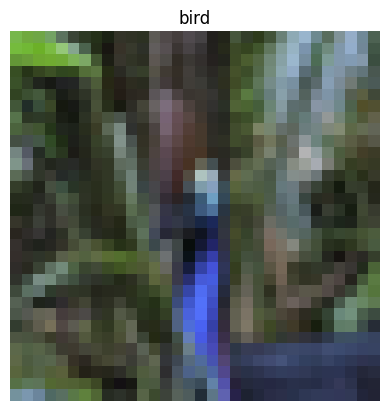

In [4]:
images,labels=next(iter(trainloader))
plt.imshow(images[0].permute(1,2,0)*0.5+0.5)
plt.title(classes[labels[0]])
plt.axis("off")
plt.show()

# Build the CNN Model

Define the Convolutional Neural Network architecture used for image classification.

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2))
        self.fc=nn.Sequential(
            nn.Linear(4*4*128,256),nn.ReLU(),nn.Linear(256,10))
    def forward(self,x):
        x=self.conv(x)
        x=x.view(x.size(0),-1)
        return self.fc(x)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=CNN().to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)


# Train the Model

Train the CNN using the training dataset by minimizing the classification loss through backpropagation.

In [6]:
epochs=10
for epoch in range(epochs):
    model.train()
    loss_sum=0
    for images,labels in trainloader:
        images,labels=images.to(device),labels.to(device)
        optimizer.zero_grad()
        out=model(images)
        loss=criterion(out,labels)
        loss.backward()
        optimizer.step()
        loss_sum+=loss.item()
    print(f"Epoch {epoch+1}/{epochs} Loss: {loss_sum/len(trainloader):.4f}")


Epoch 1/10 Loss: 1.3637
Epoch 2/10 Loss: 0.9320
Epoch 3/10 Loss: 0.7463
Epoch 4/10 Loss: 0.6090
Epoch 5/10 Loss: 0.4983
Epoch 6/10 Loss: 0.3952
Epoch 7/10 Loss: 0.3066
Epoch 8/10 Loss: 0.2338
Epoch 9/10 Loss: 0.1759
Epoch 10/10 Loss: 0.1386


# Evaluate the Model

Evaluate the trained CNN on the test dataset and calculate the overall classification accuracy.

In [7]:
model.eval()
correct=0
total=0
with torch.no_grad():
    for images,labels in testloader:
        images,labels=images.to(device),labels.to(device)
        out=model(images)
        pred=out.argmax(1)
        correct+=(pred==labels).sum().item()
        total+=labels.size(0)
print("Accuracy:",100*correct/total)


Accuracy: 76.05
